In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway, shapiro
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.multicomp import MultiComparison

In [2]:
DRIVE_DIRECTORY = Path.cwd().parent / "data"
with open(os.path.join(DRIVE_DIRECTORY, "credit.pkl"), "rb") as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = (
        pickle.load(f)
    )

In [3]:
resultados_arvores = []
resultados_random_forest = []
resultados_knn = []
resultados_logistica = []
resultados_svm = []
# resultados_rede_neural = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    arvore = DecisionTreeClassifier(
        criterion="entropy", min_samples_leaf=1, min_samples_split=5, splitter="best"
    )
    random_forest = RandomForestClassifier(
        criterion="entropy", min_samples_leaf=1, min_samples_split=5, n_estimators=10
    )
    knn = KNeighborsClassifier(n_neighbors=17, p=1)
    regresao_log = LogisticRegression(C=1.0, solver="lbfgs", tol=0.0001)
    svm = SVC(C=4.0, kernel="rbf", tol=0.1)
    rede_neural = MLPClassifier(
        activation="relu", batch_size=7, solver="adam", tol=0.0000001
    )
    scores = cross_val_score(
        arvore, X_credit_treinamento, y_credit_treinamento, cv=kfold
    )
    resultados_arvores.append(scores.mean())
    scores = cross_val_score(
        random_forest, X_credit_treinamento, y_credit_treinamento, cv=kfold
    )
    resultados_random_forest.append(scores.mean())
    scores = cross_val_score(knn, X_credit_treinamento, y_credit_treinamento, cv=kfold)
    resultados_knn.append(scores.mean())
    scores = cross_val_score(
        regresao_log, X_credit_treinamento, y_credit_treinamento, cv=kfold
    )
    resultados_logistica.append(scores.mean())
    scores = cross_val_score(svm, X_credit_treinamento, y_credit_treinamento, cv=kfold)
    resultados_svm.append(scores.mean())
    # scores = cross_val_score(
    #     rede_neural, X_credit_treinamento, y_credit_treinamento, cv=kfold
    # )
    # resultados_rede_neural.append(scores.mean())

In [4]:
print(max(resultados_arvores))
print(max(resultados_random_forest))
print(max(resultados_knn))
print(max(resultados_logistica))
print(max(resultados_svm))
# print(max(resultados_rede_neural))

0.9906666666666666
0.9886666666666667
0.9853333333333334
0.9486666666666667
0.9866666666666667


In [5]:
resultados = pd.DataFrame({
    'Arvore': resultados_arvores,
    'Random Forest': resultados_random_forest,
    'KNN': resultados_knn,
    'Regresão Logistica': resultados_logistica,
    'SVM': resultados_svm
})

In [6]:
resultados

,Arvore,Random Forest,KNN,Regresão Logistica,SVM
0,0.987333,0.984000,0.982000,0.945333,0.982000
1,0.987333,0.984667,0.984667,0.947333,0.981333
2,0.988667,0.985333,0.982000,0.946000,0.986000
3,0.986667,0.984000,0.982000,0.945333,0.984667
4,0.986000,0.985333,0.982667,0.948667,0.982000
5,0.984000,0.983333,0.982000,0.945333,0.982000
6,0.988667,0.984667,0.983333,0.944667,0.982667
7,0.986667,0.982667,0.982000,0.946000,0.982000
8,0.984667,0.982000,0.983333,0.948000,0.984667
9,0.984667,0.986667,0.985333,0.945333,0.985333


In [7]:
resultados.describe()

,Arvore,Random Forest,KNN,Regresão Logistica,SVM
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.986733,0.983667,0.982378,0.946378,0.983889
std,0.001664,0.002360,0.001834,0.001283,0.001527
min,0.983333,0.978000,0.978000,0.944667,0.981333
25%,0.986000,0.982000,0.980833,0.945333,0.982667
50%,0.986667,0.983333,0.982333,0.946000,0.984000
75%,0.987333,0.985167,0.983833,0.947333,0.985333
max,0.990667,0.988667,0.985333,0.948667,0.986667


In [8]:
resultados.var()

Arvore                0.000003
Random Forest         0.000006
KNN                   0.000003
Regresão Logistica    0.000002
SVM                   0.000002
dtype: float64

In [9]:
(resultados.std() / resultados.mean()) * 100

Arvore                0.168651
Random Forest         0.239946
KNN                   0.186645
Regresão Logistica    0.135544
SVM                   0.155211
dtype: float64

## Teste de Normalidade nos Resultados

In [10]:
alpha = 0.05

In [11]:
shapiro(resultados_arvores), shapiro(resultados_random_forest), shapiro(resultados_knn),
shapiro(resultados_logistica), shapiro(resultados_svm)

(ShapiroResult(statistic=np.float64(0.8913470665685292), pvalue=np.float64(0.0051929039948344375)),
 ShapiroResult(statistic=np.float64(0.937729746211935), pvalue=np.float64(0.07902388265690304)))

In [12]:
print(shapiro(resultados_arvores))
print(shapiro(resultados_random_forest))
print(shapiro(resultados_knn))
print(shapiro(resultados_logistica))
print(shapiro(resultados_svm))

ShapiroResult(statistic=np.float64(0.9567411813329031), pvalue=np.float64(0.2551291841002771))
ShapiroResult(statistic=np.float64(0.9824420948667741), pvalue=np.float64(0.8860942690791893))
ShapiroResult(statistic=np.float64(0.9594593600743696), pvalue=np.float64(0.30005278852330364))
ShapiroResult(statistic=np.float64(0.8913470665685292), pvalue=np.float64(0.0051929039948344375))
ShapiroResult(statistic=np.float64(0.937729746211935), pvalue=np.float64(0.07902388265690304))


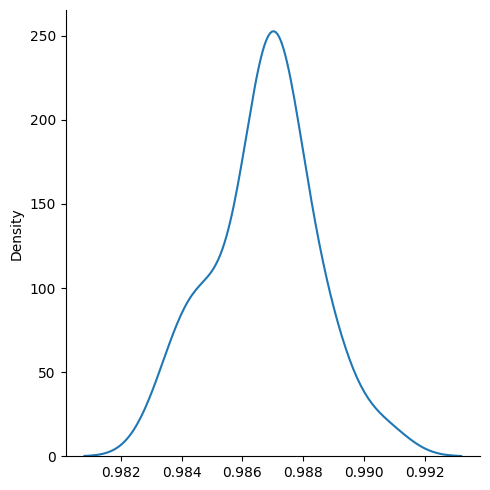

In [13]:
sns.displot(resultados_arvores, kind='kde');

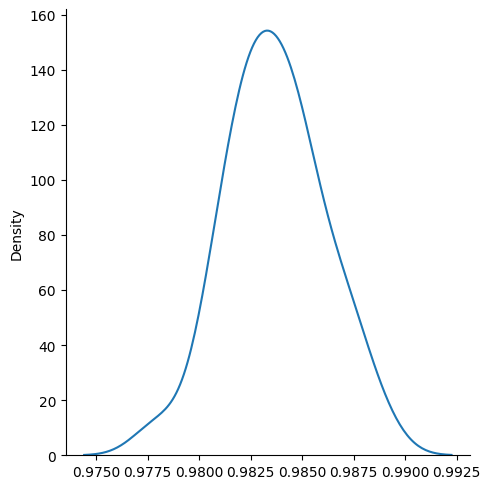

In [14]:
sns.displot(resultados_random_forest, kind='kde');

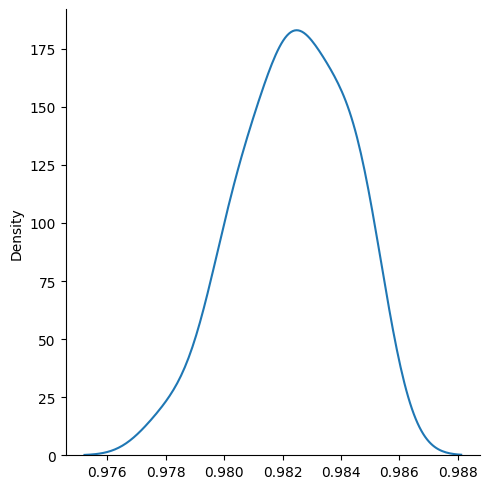

In [15]:
sns.displot(resultados_knn, kind='kde');

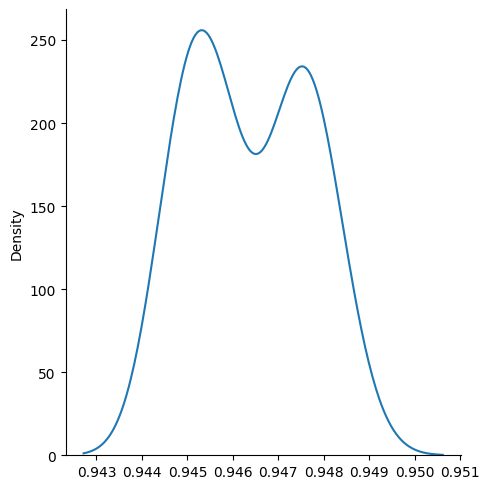

In [16]:
sns.displot(resultados_logistica, kind='kde');

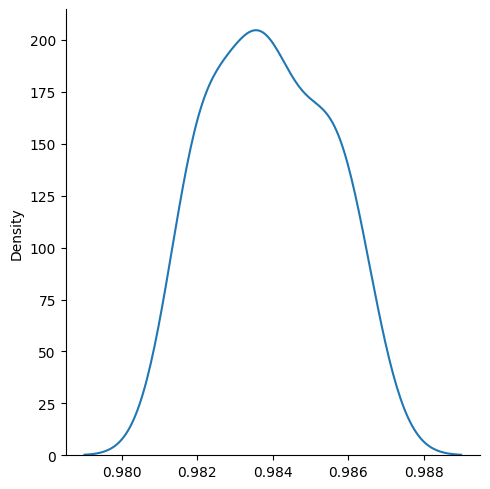

In [17]:
sns.displot(resultados_svm, kind='kde');

## Teste de Hipótese com ANOVA e Tukey

In [18]:
_, p = f_oneway(
    resultados_arvores,
    resultados_random_forest,
    resultados_knn,
    resultados_logistica,
    resultados_svm
)
p

np.float64(1.1870259857133342e-135)

In [19]:
alpha = 0.05
if p <= alpha:
    print('Hipótese nula rejeitada. Dados são diferentes')
else:
    print('Hipótese alternativa rejeitada. Resultados são iguais')

Hipótese nula rejeitada. Dados são diferentes


In [20]:
resultados_algoritmos = {
    "accuracy": np.concatenate([
        resultados_arvores,
        resultados_random_forest,
        resultados_knn,
        resultados_logistica,
        resultados_svm]),
    "algoritmo": [
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
    ]
}

In [21]:
resultados_df = pd.DataFrame(resultados_algoritmos)
resultados_df

,accuracy,algoritmo
0,0.987333,arvore
1,0.987333,arvore
2,0.988667,arvore
3,0.986667,arvore
4,0.986000,arvore
...,...,...
145,0.983333,svm
146,0.985333,svm
147,0.983333,svm
148,0.984000,svm


In [22]:
compara_algoritimos = MultiComparison(
    resultados_df['accuracy'], resultados_df['algoritmo']
)
teste_estatistico = compara_algoritimos.tukeyhsd()
print(teste_estatistico)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
       arvore           knn  -0.0044    0.0 -0.0056 -0.0031   True
       arvore     logistica  -0.0404    0.0 -0.0416 -0.0391   True
       arvore random_forest  -0.0031    0.0 -0.0043 -0.0018   True
       arvore           svm  -0.0028    0.0 -0.0041 -0.0016   True
          knn     logistica   -0.036    0.0 -0.0373 -0.0347   True
          knn random_forest   0.0013  0.043     0.0  0.0026   True
          knn           svm   0.0015 0.0104  0.0002  0.0028   True
    logistica random_forest   0.0373    0.0   0.036  0.0386   True
    logistica           svm   0.0375    0.0  0.0362  0.0388   True
random_forest           svm   0.0002 0.9885  -0.001  0.0015  False
------------------------------------------------------------------


In [23]:
resultados.mean()

Arvore                0.986733
Random Forest         0.983667
KNN                   0.982378
Regresão Logistica    0.946378
SVM                   0.983889
dtype: float64

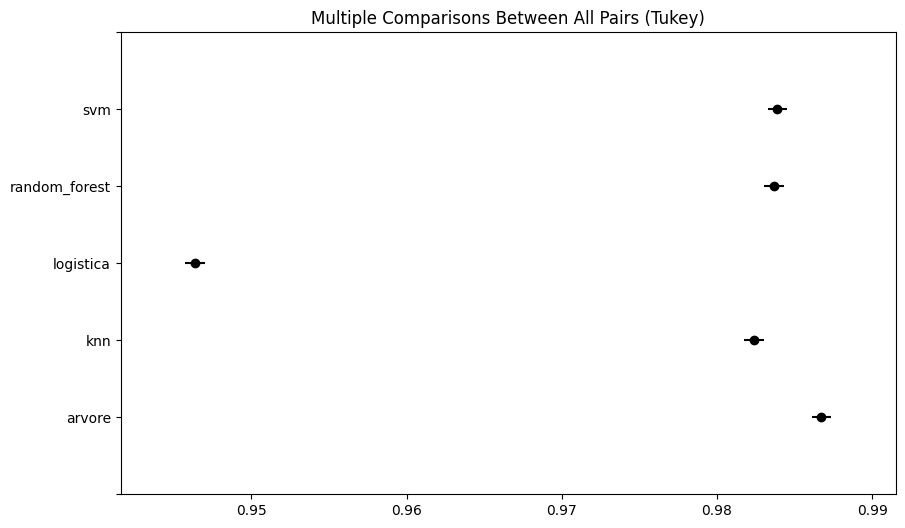

In [24]:
teste_estatistico.plot_simultaneous();